In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df= pd.read_csv(r'C:\Users\HP\Downloads\pakistan_house_price_data.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27890 entries, 0 to 27889
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     27890 non-null  int64  
 1   property_id    27890 non-null  int64  
 2   location_id    27890 non-null  int64  
 3   page_url       27890 non-null  str    
 4   property_type  27890 non-null  str    
 5   price          27890 non-null  int64  
 6   location       27890 non-null  str    
 7   city           27890 non-null  str    
 8   province_name  27890 non-null  str    
 9   latitude       27890 non-null  float64
 10  longitude      27890 non-null  float64
 11  baths          27890 non-null  int64  
 12  purpose        27890 non-null  str    
 13  bedrooms       27890 non-null  int64  
 14  date_added     27890 non-null  str    
 15  agency         20266 non-null  str    
 16  agent          20266 non-null  str    
 17  Total_Area     27890 non-null  float64
dtypes: float64(3), in

In [5]:
df.columns

Index(['Unnamed: 0', 'property_id', 'location_id', 'page_url', 'property_type',
       'price', 'location', 'city', 'province_name', 'latitude', 'longitude',
       'baths', 'purpose', 'bedrooms', 'date_added', 'agency', 'agent',
       'Total_Area'],
      dtype='str')

In [6]:
df2= df.drop(['property_id', 'location_id', 'page_url','agency', 'agent','latitude', 'longitude','Unnamed: 0'], axis= 1)

In [11]:
df2['location'].nunique()

207

In [134]:
df2.head()

,property_type,price,location,city,province_name,baths,purpose,bedrooms,date_added,Total_Area
0,Flat,6900000,E-11,Islamabad,Islamabad Capital,3,For Sale,3,05-04-19,15246.0
1,House,16500000,G-15,Islamabad,Islamabad Capital,6,For Sale,5,7/17/2019,2178.0
2,House,43500000,Bani Gala,Islamabad,Islamabad Capital,4,For Sale,4,04-05-19,10890.0
3,House,7000000,DHA Defence,Islamabad,Islamabad Capital,3,For Sale,3,07-10-19,2178.0
4,House,34500000,Ghauri Town,Islamabad,Islamabad Capital,8,For Sale,8,04-05-19,87120.0


In [135]:
df2.isnull().sum()

property_type    0
price            0
location         0
city             0
province_name    0
baths            0
purpose          0
bedrooms         0
date_added       0
Total_Area       0
dtype: int64

In [136]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 27890 entries, 0 to 27889
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  27890 non-null  str    
 1   price          27890 non-null  int64  
 2   location       27890 non-null  str    
 3   city           27890 non-null  str    
 4   province_name  27890 non-null  str    
 5   baths          27890 non-null  int64  
 6   purpose        27890 non-null  str    
 7   bedrooms       27890 non-null  int64  
 8   date_added     27890 non-null  str    
 9   Total_Area     27890 non-null  float64
dtypes: float64(1), int64(3), str(6)
memory usage: 2.1 MB


In [137]:
print(df2.dtypes)

property_type        str
price              int64
location             str
city                 str
province_name        str
baths              int64
purpose              str
bedrooms           int64
date_added           str
Total_Area       float64
dtype: object


In [138]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', dayfirst=True, errors='coerce')

In [11]:
df['date_added'].info()

<class 'pandas.Series'>
RangeIndex: 27890 entries, 0 to 27889
Series name: date_added
Non-Null Count  Dtype         
--------------  -----         
27890 non-null  datetime64[us]
dtypes: datetime64[us](1)
memory usage: 218.0 KB


In [12]:
print(df2.dtypes)

property_type        str
price              int64
location             str
city                 str
province_name        str
baths              int64
purpose              str
bedrooms           int64
date_added           str
Total_Area       float64
dtype: object


In [139]:
df2.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
27885    False
27886    False
27887    False
27888    False
27889    False
Length: 27890, dtype: bool

In [169]:
top10= df2.sort_values('price',ascending=False)
top10 = top10.head(10)
print(top10[['location', 'property_type', 'price','purpose']])

      location property_type      price   purpose
24009      F-6         House  900000000  For Sale
2117       F-6         House  850000000  For Sale
23691      F-6         House  850000000  For Sale
23693      F-6         House  850000000  For Sale
92         F-6         House  850000000  For Sale
19113      F-6         House  750000000  For Sale
20512      F-6         House  750000000  For Sale
22060      F-6         House  700000000  For Sale
23805      F-6         House  600000000  For Sale
18427      F-7         House  550000000  For Sale


In [171]:
Costly=top10

In [173]:
Affordable=low10

In [160]:
low10 = df2[df2['purpose'] == 'For Sale']          
low10 = low10.sort_values('price', ascending=True) 
low10 = low10.head(10)
print(low10[['location', 'property_type', 'price', 'purpose']])


       location  property_type   price   purpose
26828  PWD Road          House       1  For Sale
27491      G-11           Flat   23000  For Sale
27408      I-10  Lower Portion   35000  For Sale
15613      G-15  Lower Portion   37000  For Sale
27494      G-13  Lower Portion   42000  For Sale
27403      G-11          House   50000  For Sale
21892      E-11  Upper Portion   55000  For Sale
26815      G-11          House   70000  For Sale
19433      F-11           Flat   76000  For Sale
27854      D-12          House  100000  For Sale


In [161]:
top10_avg = top10['price'].mean()
low10_avg = low10['price'].mean()
print("Top 10 Avg Price:", top10_avg)
print("Bottom 10 Avg Price:", low10_avg)


Top 10 Avg Price: 765000000.0
Bottom 10 Avg Price: 48800.1


In [162]:
price_gap = top10_avg - low10_avg
print("Price Gap:", price_gap)


Price Gap: 764951199.9


In [163]:

top10 = df2.sort_values('price', ascending=False).head(10)
low10 = df2.sort_values('price', ascending=True).head(10)

print("Top 10 Locations:")
print(top10['location'].value_counts())


print("\nBottom 10 Locations:")
print(low10['location'].value_counts())


Top 10 Locations:
location
F-6    9
F-7    1
Name: count, dtype: int64

Bottom 10 Locations:
location
PWD Housing Scheme    2
PWD Road              1
G-13                  1
F-7                   1
Chatha Bakhtawar      1
E-11                  1
Al Huda Town          1
Alipur Farash         1
Ghauri Town           1
Name: count, dtype: int64


In [23]:
df2.groupby('property_type')['price'].max()

property_type
Farm House       500000000
Flat             142000000
House            900000000
Lower Portion      5800000
Penthouse        130000000
Room              22000000
Upper Portion     65000000
Name: price, dtype: int64

In [24]:
df2.groupby('property_type')['price'].min()

property_type
Farm House       12000
Flat              6000
House                1
Lower Portion    10000
Penthouse        18000
Room              1000
Upper Portion     8000
Name: price, dtype: int64

In [36]:
df2.groupby('location')['price'].agg(['mean','max','min'])


,mean,max,min
location,,,
12th Avenue,1.502000e+07,30000000,40000
7th Avenue,8.707079e+06,150000000,10000
9th Avenue,5.177417e+06,42500000,15000
AGHOSH,2.500583e+07,35000000,35000
Abdullah Garden,7.395444e+06,14500000,16000
...,...,...,...
Victoria Heights,2.500000e+04,25000,25000
Wapda Town,6.900000e+06,7000000,6800000
Zaraj Housing Scheme,1.062138e+07,32500000,12000


In [165]:
top10 = df2.sort_values('price', ascending=False).head(10)
low10 = df2.sort_values('price', ascending=True).head(10)

print("Top 10 Property Types:")
print(top10['property_type'].value_counts())

print("\nBottom 10 Property Types:")
print(low10['property_type'].value_counts())


Top 10 Property Types:
property_type
House    10
Name: count, dtype: int64

Bottom 10 Property Types:
property_type
Room     8
House    2
Name: count, dtype: int64


In [166]:
top10 = df2.sort_values('price', ascending=False).head(10)
low10 = df2.sort_values('price', ascending=True).head(10)

print("Top 10 Purpose Distribution:")
print(top10['purpose'].value_counts())

print("\nBottom 10 Purpose Distribution:")
print(low10['purpose'].value_counts())


Top 10 Purpose Distribution:
purpose
For Sale    10
Name: count, dtype: int64

Bottom 10 Purpose Distribution:
purpose
For Rent    9
For Sale    1
Name: count, dtype: int64


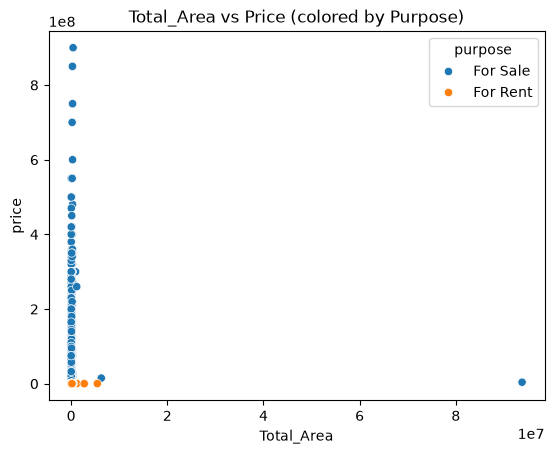

In [168]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df2, x='Total_Area', y='price', hue='purpose')
plt.title("Total_Area vs Price (colored by Purpose)")
plt.show()


<Axes: xlabel='price', ylabel='Count'>

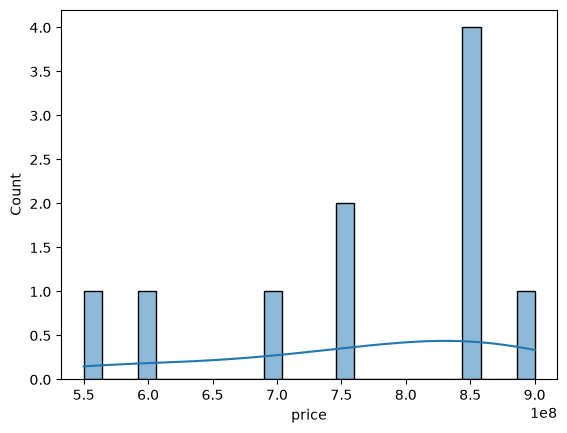

In [176]:
sns.histplot(Costly['price'], bins=25, kde=True)

<Axes: xlabel='price', ylabel='Count'>

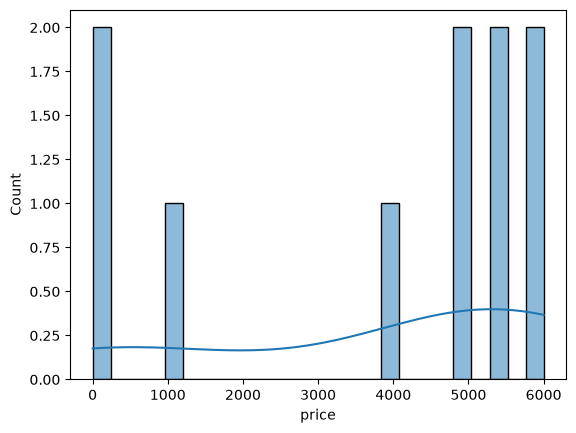

In [177]:
sns.histplot(Affordable['price'], bins=25, kde=True)

<Axes: xlabel='bedrooms', ylabel='price'>

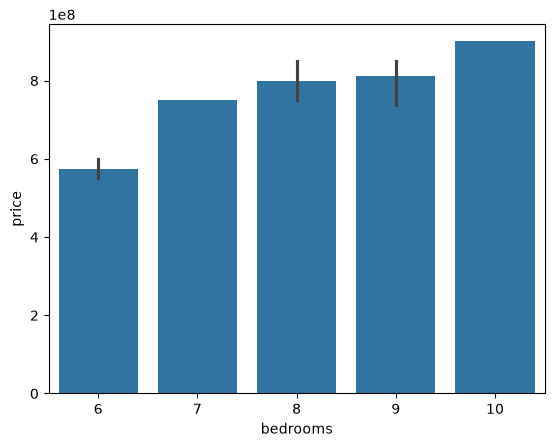

In [178]:
sns.barplot(x='bedrooms', y='price', data=Costly)

<Axes: xlabel='bedrooms', ylabel='price'>

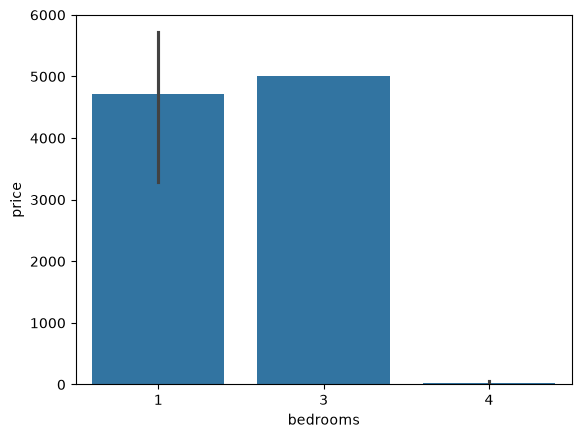

In [179]:
sns.barplot(x='bedrooms', y='price', data=Affordable)

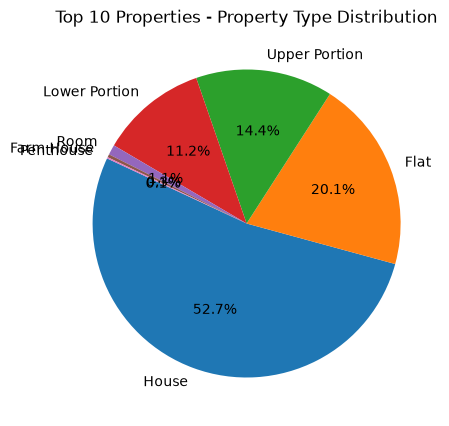

In [223]:
import matplotlib.pyplot as plt

# Property type distribution in top 10
type_counts = df2['property_type'].value_counts()
plt.figure(figsize=(6,5))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=155)
plt.title("Top 10 Properties - Property Type Distribution")
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_16612\615018828.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.index, y=type_counts.values, palette="Set2")


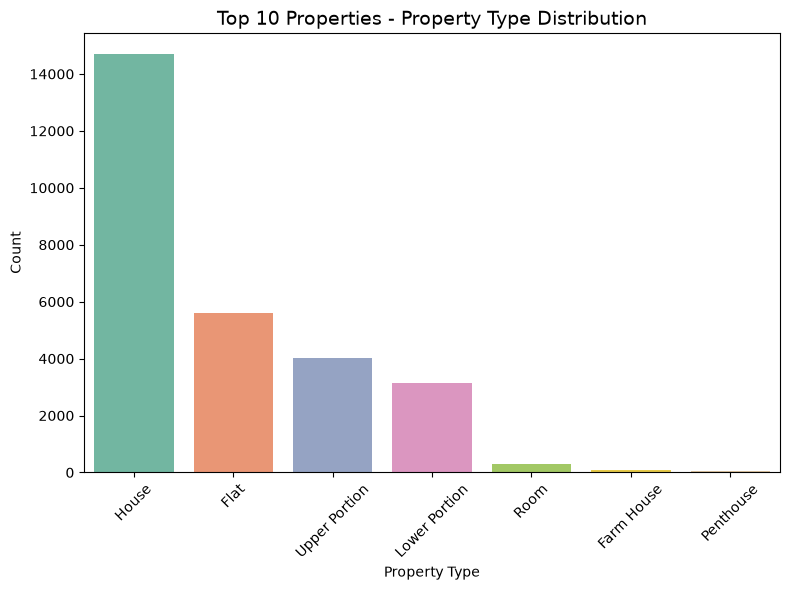

In [222]:
type_counts = df2['property_type'].value_counts()

# Seaborn barplot for distribution
plt.figure(figsize=(8,6))
sns.barplot(x=type_counts.index, y=type_counts.values, palette="Set2")

plt.title("Top 10 Properties - Property Type Distribution", fontsize=14)
plt.xlabel("Property Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()